Loaded 23 papers.
Remaining papers after cleaning: 23


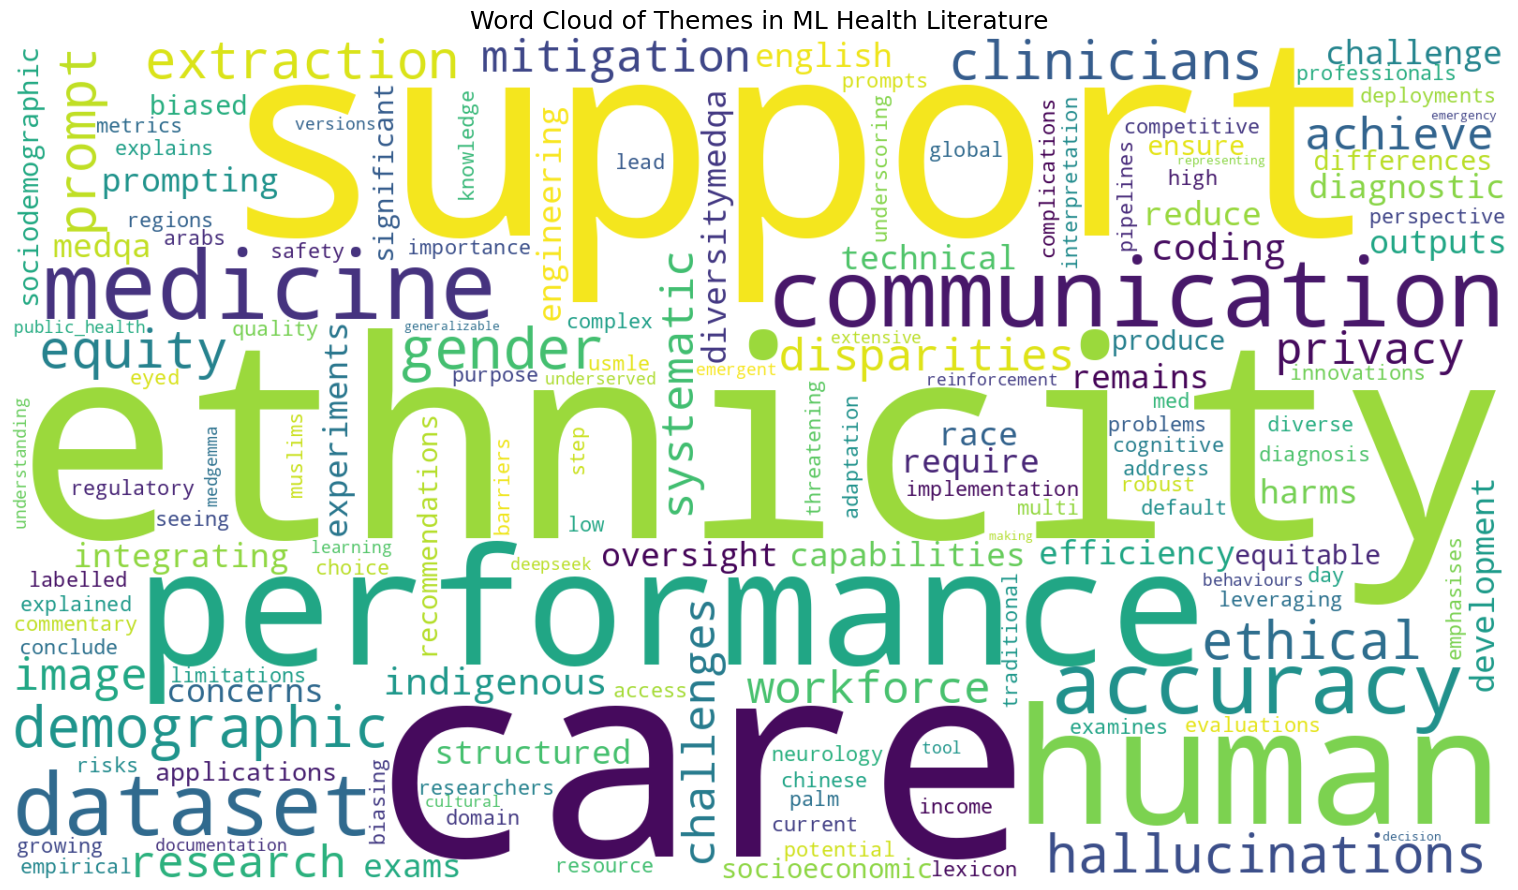

Saved word cloud to: ml_health_wordcloud.png

Done.


In [ ]:


import re
from collections import Counter, defaultdict

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer


CSV_PATH = "/content/references.csv"

df = pd.read_csv(CSV_PATH)

required_cols = {"Title", "Abstract"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["Title"] = df["Title"].fillna("")
df["Abstract"] = df["Abstract"].fillna("")

df["text"] = (df["Title"] + " " + df["Abstract"]).str.strip()

df = df[df["text"].str.len() > 0].copy()

print(f"Loaded {len(df)} papers.")


stopwords = set(ENGLISH_STOP_WORDS)

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stopwords = set(ENGLISH_STOP_WORDS)

custom_stopwords = {
    # generic academic/reporting words
    "study", "studies", "paper", "papers", "article", "articles",
    "author", "authors", "review", "reports", "report",
    "result", "results", "method", "methods", "conclusion", "conclusions",
    "objective", "objectives", "background", "aim", "aims",
    "introduction", "discussion", "findings", "finding",
    "using", "used", "use", "based", "approach", "approaches",
    "analysis", "analyses", "data", "information",
    "show", "shows", "showed", "demonstrate", "demonstrates", "demonstrated",
    "evaluate", "evaluated", "evaluation", "assess", "assessment",
    "propose", "proposed", "include", "included", "including",
    "improve", "improved", "improving", "need", "needed",
    "introduces", "highlight", "highlights", "discusses", "developed",
    "better", "specific", "general", "multiple", "real", "safe",
    "work", "question", "questions", "answer", "answering",
    "parameter", "parameters", "task", "tasks", "source", "sources",
    "benchmark", "status", "world", "life", "self",

    # overly generic domain words
    "health", "healthcare", "medical", "clinical", "patient", "patients",
    "model", "models", "system", "systems", "practice", "practical",
    "training", "trained", "workflow", "workflows", "framework",
    "text", "open", "case", "cases",

    # LLM-paper boilerplate
    "llm", "llms", "gpt", "chatgpt", "llama", "openai",
    "artificial_intelligence", "artificial", "intelligence",
    "large", "language", "language_model", "language_models",

    # noisy corpus-specific words from your cloud
    "asks", "culturally", "million", "billion"
}

stopwords |= custom_stopwords


phrase_map = {
    r"\bmachine learning\b": "machine_learning",
    r"\bdeep learning\b": "deep_learning",
    r"\bartificial intelligence\b": "artificial_intelligence",
    r"\bnatural language processing\b": "natural_language_processing",
    r"\belectronic health records\b": "electronic_health_records",
    r"\belectronic medical records\b": "electronic_medical_records",
    r"\bclinical decision support\b": "clinical_decision_support",
    r"\bmedical imaging\b": "medical_imaging",
    r"\bpublic health\b": "public_health",
    r"\bhealth informatics\b": "health_informatics",
    r"\bintensive care unit\b": "intensive_care_unit",
    r"\brandom forest\b": "random_forest",
    r"\bsupport vector machine\b": "support_vector_machine",
    r"\bneural network\b": "neural_network",
    r"\bconvolutional neural network\b": "convolutional_neural_network",
    r"\brecurrent neural network\b": "recurrent_neural_network",
    r"\btransformer model\b": "transformer_model",
    r"\bremote monitoring\b": "remote_monitoring",
    r"\brisk prediction\b": "risk_prediction",
    r"\bprecision medicine\b": "precision_medicine",
    r"\bmental health\b": "mental_health",
    r"\bcomputer vision\b": "computer_vision",
    r"\btime series\b": "time_series",
    r"\bwearable devices\b": "wearable_devices",
    r"\bdigital health\b": "digital_health"
}

phrase_map.update({
    r"\bgender bias\b": "gender_bias",
    r"\brace bias\b": "race_bias",
    r"\bracial bias\b": "racial_bias",
    r"\bethnic bias\b": "ethnic_bias",
    r"\bethnicity\b": "ethnicity",
    r"\bracial disparities\b": "racial_disparities",
    r"\bgender disparities\b": "gender_disparities",
    r"\bsocioeconomic\b": "socioeconomic",
    r"\bincome\b": "income",
    r"\bdemographic\b": "demographic",
    r"\bminority\b": "minority",
    r"\bunderserved\b": "underserved",
})



def normalize_phrases(text: str) -> str:
    text = text.lower()
    for pattern, replacement in phrase_map.items():
        text = re.sub(pattern, replacement, text)
    return text


def clean_text(text: str) -> str:
    text = normalize_phrases(text)

    # Remove URLs, emails, citations like [12], and numbers
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"\[\d+\]", " ", text)
    text = re.sub(r"\b\d+(?:\.\d+)?\b", " ", text)

    # Keep letters, underscores, and spaces
    text = re.sub(r"[^a-zA-Z_\s]", " ", text)

    # Collapse spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Remove short tokens and stopwords
    tokens = []
    for token in text.split():
        if len(token) < 3:
            continue
        if token in stopwords:
            continue
        tokens.append(token)

    return " ".join(tokens)

df["clean_text"] = df["text"].apply(clean_text)

# Remove rows that become empty after cleaning
df = df[df["clean_text"].str.len() > 0].copy()

print(f"Remaining papers after cleaning: {len(df)}")


all_tokens = " ".join(df["clean_text"]).split()
term_freq = Counter(all_tokens)

boost_terms = {
    "gender_bias": 4,
    "race_bias": 4,
    "racial_bias": 4,
    "ethnic_bias": 4,
    "gender": 3,
    "race": 3,
    "ethnicity": 3,
    "demographic": 2,
    "socioeconomic": 2,
    "underserved": 2,
    "minority": 2,
    "racial_disparities": 3,
    "gender_disparities": 3,
    "communication": 3,
    "cultural": 0.25
}

for term, mult in boost_terms.items():
    if term in term_freq:
        term_freq[term] *= mult

term_freq.pop("bias", None)
term_freq.pop("biases", None)
term_freq.pop("reasoning", None)
term_freq.pop("strategies", None)



wc = WordCloud(
    width=1600,
    height=900,
    background_color="white",
    max_words=150,
    collocations=False
).generate_from_frequencies(term_freq)

plt.figure(figsize=(16, 9))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Themes in ML Health Literature", fontsize=18)
plt.tight_layout()
plt.savefig("ml_health_wordcloud.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved word cloud to: ml_health_wordcloud.png")



print("\nDone.")